# Intern Skill Gap Analysis & Training Recommendation


## Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")


Libraries imported successfully!


## Load the Datasets


In [2]:
intern_profiles = pd.read_csv("intern_profiles.csv")
job_descriptions = pd.read_csv("industry_job_descriptions.csv")
industry_demand = pd.read_csv("industry_skill_demand.csv")

print("Intern profiles:", intern_profiles.shape)
print("Job descriptions:", job_descriptions.shape)
print("Industry demand:", industry_demand.shape)

display(intern_profiles.head())
display(job_descriptions.head())
display(industry_demand.head())


Intern profiles: (250, 6)
Job descriptions: (5, 4)
Industry demand: (40, 4)


,intern_id,intern_name,target_role,skills,experience_level,projects_completed
0,INT001,Intern 001,Data Scientist,"NumPy, SQL, Power BI, Python, Machine Learning...",Beginner,0
1,INT002,Intern 002,Data Scientist,"Python, Machine Learning, SQL, Power BI, NumPy",Beginner,4
2,INT003,Intern 003,Data Analyst,"Tableau, Power BI, Communication, Excel, Pandas",Beginner,2
3,INT004,Intern 004,Data Scientist,"SQL, Pandas, Power BI, Machine Learning, Stati...",Beginner,3
4,INT005,Intern 005,Data Scientist,"Statistics, Machine Learning, SQL, Python, Pow...",Intermediate,2


,job_id,job_title,required_skills,job_description
0,JOB001,Data Scientist,"Python, SQL, Pandas, NumPy, Machine Learning, ...",We are seeking a Data Scientist intern to supp...
1,JOB002,Machine Learning Engineer,"Python, SQL, Machine Learning, Scikit-learn, T...",We are seeking a Machine Learning Engineer int...
2,JOB003,Data Analyst,"SQL, Excel, Power BI, Python, Pandas, Statisti...",We are seeking a Data Analyst intern to suppor...
3,JOB004,Software Developer,"Python, Java, Git, SQL, APIs, OOP, Testing, Pr...",We are seeking a Software Developer intern to ...
4,JOB005,Web Developer,"HTML, CSS, JavaScript, React, APIs, Git, Respo...",We are seeking a Web Developer intern to suppo...


,role,skill,industry_demand,demand_score
0,Data Scientist,Python,High,88
1,Data Scientist,SQL,High,98
2,Data Scientist,Pandas,High,77
3,Data Scientist,NumPy,High,98
4,Data Scientist,Machine Learning,Medium,78


## Understand the Data



In [3]:
print("Missing values in intern profiles:")
print(intern_profiles.isnull().sum())

print("\nMissing values in job descriptions:")
print(job_descriptions.isnull().sum())


Missing values in intern profiles:
intern_id             0
intern_name           0
target_role           0
skills                0
experience_level      0
projects_completed    0
dtype: int64

Missing values in job descriptions:
job_id             0
job_title          0
required_skills    0
job_description    0
dtype: int64


## Skill Matching


In [4]:
def skill_set(text):
    return {x.strip().lower() for x in str(text).split(",") if x.strip()}

def analyze_gap(intern_row):
    role = intern_row["target_role"]
    job = job_descriptions[job_descriptions["job_title"] == role].iloc[0]

    intern_skills = skill_set(intern_row["skills"])
    required_skills = skill_set(job["required_skills"])

    matched = intern_skills.intersection(required_skills)
    missing = required_skills - intern_skills

    match_pct = (len(matched) / len(required_skills)) * 100
    gap_pct = 100 - match_pct

    return pd.Series({
        "matched_skills": ", ".join(sorted(matched)),
        "missing_skills": ", ".join(sorted(missing)),
        "skill_match_percentage": round(match_pct, 2),
        "skill_gap_percentage": round(gap_pct, 2)
    })

gap_results = intern_profiles.apply(analyze_gap, axis=1)
intern_gap_analysis = pd.concat([intern_profiles, gap_results], axis=1)

display(intern_gap_analysis.head())


,intern_id,intern_name,target_role,skills,experience_level,projects_completed,matched_skills,missing_skills,skill_match_percentage,skill_gap_percentage
0,INT001,Intern 001,Data Scientist,"NumPy, SQL, Power BI, Python, Machine Learning...",Beginner,0,"machine learning, numpy, pandas, power bi, pyt...","git, statistics",75.0,25.0
1,INT002,Intern 002,Data Scientist,"Python, Machine Learning, SQL, Power BI, NumPy",Beginner,4,"machine learning, numpy, power bi, python, sql","git, pandas, statistics",62.5,37.5
2,INT003,Intern 003,Data Analyst,"Tableau, Power BI, Communication, Excel, Pandas",Beginner,2,"communication, excel, pandas, power bi, tableau","python, sql, statistics",62.5,37.5
3,INT004,Intern 004,Data Scientist,"SQL, Pandas, Power BI, Machine Learning, Stati...",Beginner,3,"git, machine learning, pandas, power bi, pytho...",numpy,87.5,12.5
4,INT005,Intern 005,Data Scientist,"Statistics, Machine Learning, SQL, Python, Pow...",Intermediate,2,"machine learning, pandas, power bi, python, sq...","git, numpy",75.0,25.0


## TF-IDF: NLP Representation

### What is TF-IDF?

TF-IDF converts text into numbers.

Here, we combine the intern's skills and the job description and use TF-IDF to represent them numerically.

This allows us to compare text-based skill profiles.


In [5]:
intern_profiles["skill_text"] = (
    intern_profiles["target_role"] + " " + intern_profiles["skills"]
)

vectorizer = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[\w+#.-]+\b"
)

tfidf_matrix = vectorizer.fit_transform(intern_profiles["skill_text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Number of features:", len(vectorizer.get_feature_names_out()))


TF-IDF matrix shape: (250, 35)
Number of features: 35


##  K-Means Clustering



In [6]:
k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

intern_profiles["cluster"] = kmeans.fit_predict(tfidf_matrix)

print("Cluster sizes:")
print(intern_profiles["cluster"].value_counts().sort_index())


Cluster sizes:
cluster
0    64
1    35
2    57
3    48
4    46
Name: count, dtype: int64


## Check Cluster Quality


In [7]:
silhouette = silhouette_score(tfidf_matrix, intern_profiles["cluster"])
print(f"Silhouette Score: {silhouette:.3f}")


Silhouette Score: 0.412


## Visualize Intern Clusters


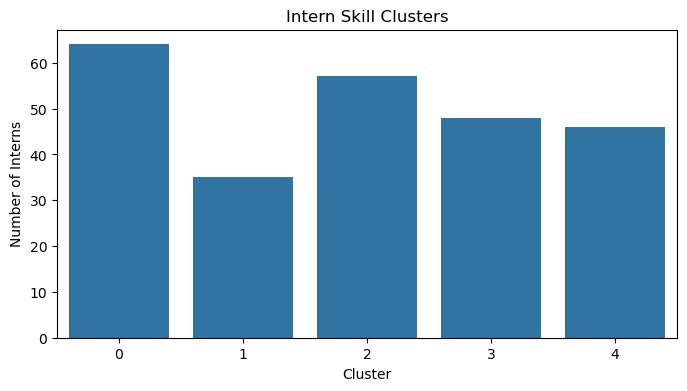

In [8]:
plt.figure(figsize=(8, 4))
sns.countplot(data=intern_profiles, x="cluster")
plt.title("Intern Skill Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Interns")
plt.show()


## 9. Find Common Skills in Each Cluster

This section shows the most common skills for each cluster, making the groups easier to interpret.


In [9]:
def get_skill_counts(series):
    counts = {}
    for text in series:
        for skill in str(text).split(","):
            skill = skill.strip()
            counts[skill] = counts.get(skill, 0) + 1
    return sorted(counts.items(), key=lambda x: x[1], reverse=True)

for cluster_id in sorted(intern_profiles["cluster"].unique()):
    cluster_data = intern_profiles[intern_profiles["cluster"] == cluster_id]
    print(f"\nCluster {cluster_id}")
    print(get_skill_counts(cluster_data["skills"])[:8])



Cluster 0
[('Power BI', 51), ('Statistics', 51), ('Python', 49), ('Excel', 45), ('Pandas', 45), ('Communication', 41), ('SQL', 40), ('Tableau', 37)]

Cluster 1
[('Problem Solving', 30), ('JavaScript', 28), ('Responsive Design', 28), ('HTML', 27), ('React', 24), ('CSS', 22), ('Git', 22), ('APIs', 20)]

Cluster 2
[('Git', 40), ('APIs', 39), ('Problem Solving', 39), ('Python', 38), ('OOP', 38), ('SQL', 37), ('Java', 34), ('Testing', 34)]

Cluster 3
[('Machine Learning', 38), ('Pandas', 38), ('NumPy', 35), ('Git', 34), ('Power BI', 33), ('Statistics', 33), ('SQL', 32), ('Python', 30)]

Cluster 4
[('Statistics', 38), ('Docker', 34), ('Scikit-learn', 32), ('Git', 32), ('SQL', 31), ('TensorFlow', 29), ('Python', 28), ('Machine Learning', 25)]


## 10. Industry Skill Demand

Industry demand tells us which skills are important for each role.

We use this information together with each intern's missing skills to prioritize training.


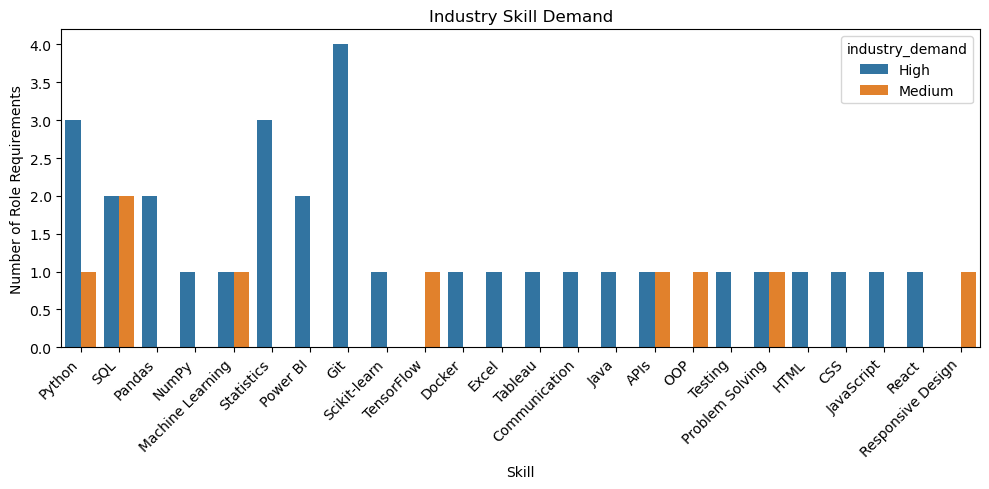

In [10]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=industry_demand,
    x="skill",
    hue="industry_demand"
)
plt.title("Industry Skill Demand")
plt.xlabel("Skill")
plt.ylabel("Number of Role Requirements")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Generate Training Recommendations


In [11]:
def recommend_training(intern_id, top_n=5):
    row = intern_gap_analysis[intern_gap_analysis["intern_id"] == intern_id].iloc[0]
    role = row["target_role"]

    missing = [x.strip() for x in str(row["missing_skills"]).split(",") if x.strip()]

    if not missing:
        return pd.DataFrame(columns=[
            "intern_id", "role", "missing_skill", "demand_score",
            "industry_demand", "recommended_training"
        ])

    demand = industry_demand[
        (industry_demand["role"] == role) &
        (industry_demand["skill"].isin(missing))
    ].copy()

    demand["recommended_training"] = demand["skill"].map(
        lambda x: training_map.get(x, f"{x} Training")
    )

    result = demand.sort_values(
        "demand_score", ascending=False
    ).head(top_n)

    result.insert(0, "intern_id", intern_id)
    result.insert(1, "role", role)

    return result[[
        "intern_id", "role", "skill", "demand_score",
        "industry_demand", "recommended_training"
    ]].rename(columns={"skill": "missing_skill"})

# Example intern
selected_intern_id = "INT001"
recommendations = recommend_training(selected_intern_id)

print("Training recommendations:")
display(recommendations)


ValueError: cannot insert role, already exists

## 12. Create a Complete Gap Report


In [ ]:
all_recommendations = []

for intern_id in intern_gap_analysis["intern_id"]:
    rec = recommend_training(intern_id, top_n=5)
    if not rec.empty:
        all_recommendations.append(rec)

if all_recommendations:
    training_report = pd.concat(all_recommendations, ignore_index=True)
else:
    training_report = pd.DataFrame()

display(training_report.head(20))


## Identify the Most Common Skill Deficiencies



In [ ]:
missing_counts = {}

for text in intern_gap_analysis["missing_skills"]:
    for skill in str(text).split(","):
        skill = skill.strip()
        if skill:
            missing_counts[skill] = missing_counts.get(skill, 0) + 1

common_gaps = (
    pd.DataFrame(
        list(missing_counts.items()),
        columns=["skill", "number_of_interns_with_gap"]
    )
    .sort_values("number_of_interns_with_gap", ascending=False)
)

display(common_gaps.head(10))


In [ ]:
plt.figure(figsize=(9, 5))
top_gaps = common_gaps.head(10)

sns.barplot(
    data=top_gaps,
    x="number_of_interns_with_gap",
    y="skill"
)

plt.title("Top Skill Deficiencies Among Interns")
plt.xlabel("Number of Interns")
plt.ylabel("Missing Skill")
plt.tight_layout()
plt.show()


## Example: Analyze One Intern



In [ ]:
selected_intern_id = "INT001"

selected_report = intern_gap_analysis[
    intern_gap_analysis["intern_id"] == selected_intern_id
]

display(selected_report[[
    "intern_id",
    "intern_name",
    "target_role",
    "skills",
    "matched_skills",
    "missing_skills",
    "skill_match_percentage",
    "skill_gap_percentage",
    "cluster"
]])

print("\nRecommended Training:")
display(recommend_training(selected_intern_id, top_n=5))


## Export Results



In [ ]:
intern_gap_analysis.to_csv(
    "intern_skill_gap_analysis.csv",
    index=False
)

with pd.ExcelWriter(
    "intern_skill_gap_analysis_report.xlsx",
    engine="openpyxl"
) as writer:
    intern_gap_analysis.to_excel(
        writer,
        sheet_name="Skill Gap Analysis",
        index=False
    )
    training_report.to_excel(
        writer,
        sheet_name="Training Recommendations",
        index=False
    )
    common_gaps.to_excel(
        writer,
        sheet_name="Common Skill Gaps",
        index=False
    )

print("Reports exported successfully!")
